# Modeling HUPA0003's using an RNN, glucose are considered as the only input at each step t  

In addition, in this notebook we take an approach of the form sequence to vector i.e. given a sequence we predict just a single step instead of several steps 

In [79]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

## Get data 

In [80]:
data = pd.read_csv('../Data/Preprocessed/HUPA0009P.csv', sep=';')
data['time'] = pd.to_datetime(data['time'])

In [81]:
data

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
0,2018-09-19 14:35:00,256.927536,9.152000,90.142857,69.0,0.108333,0.0,0.0
1,2018-09-19 14:40:00,257.434783,27.272959,116.783582,194.0,0.108333,0.0,0.0
2,2018-09-19 14:45:00,257.942029,30.293120,113.468354,574.0,0.108333,0.0,0.0
3,2018-09-19 14:50:00,258.449275,22.788480,106.397351,322.0,0.108333,0.0,0.0
4,2018-09-19 14:55:00,258.956522,7.321600,83.112069,12.0,0.108333,0.0,0.0
...,...,...,...,...,...,...,...,...
3807,2018-10-02 19:50:00,280.813084,14.094080,97.961538,110.0,0.112500,0.0,0.0
3808,2018-10-02 19:55:00,280.859813,10.067200,90.296296,71.0,0.112500,0.0,0.0
3809,2018-10-02 20:00:00,280.906542,9.243520,90.481481,40.0,0.112500,0.0,0.0
3810,2018-10-02 20:05:00,280.953271,10.799360,96.027778,66.0,0.112500,0.0,0.0


## Architecture 

- input_size = 1 (Size of vector at each time step)
- hidden_size = 4 (Number of recurrent neurons)
- batch_size = 12

In [82]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

Prepare data 

Import our own class 

In [83]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [84]:
batch_size = 12
input_size = 1
hidden_size = 8
window_size = 4
steps_ahead = 3 

In [85]:
train = Window_Regressor_Sequence_to_scalar(data['glucose'][:-batch_size], window_size=window_size, horizon=steps_ahead).generate_data_set()
test = Window_Regressor_Sequence_to_scalar(data['glucose'][-batch_size:], window_size=window_size, horizon=steps_ahead).generate_data_set()

In [86]:
train_data = torch.tensor(train.values, dtype=torch.float32)
test_data = torch.tensor(test.values, dtype=torch.float32)

In [ ]:
# Separar datos en train y validation
train_size = int(0.8 * len(train_data))
train_data, val_data = train_data[:train_size], train_data[train_size:]

# Crear los DataLoaders
train_dataset = TensorDataset(train_data)
val_dataset = TensorDataset(val_data)
test_dataset = TensorDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Define the model

In [96]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn_1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.linear_layer = nn.Linear(in_features=hidden_size, out_features=1)
        
    
    def forward(self, x):
        output_recurrent_layer, _ = self.rnn_1(x) ## receives as input (Batch, Window, Input_size) => (Batch, Window, Hidden_size)
        prediction = self.linear_layer(output_recurrent_layer[:, -1, :])  ## We want to keep just the last output for the last element of each sequence 
        return prediction.squeeze(-1) ## To obtain (Batch,) instead of (Batch, 1)
        

In [110]:
model = RNN(input_size=input_size, hidden_size=hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()
epochs = 500

In [111]:
print(model)

RNN(
  (rnn_1): LSTM(1, 8, batch_first=True)
  (linear_layer): Linear(in_features=8, out_features=1, bias=True)
)


Train the model 

In [ ]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 10  # Número de épocas a esperar antes de detener si no hay mejora
counter = 0    # Contador para el early stopping

for e in range(epochs):
    # Training
    model.train()
    epoch_losses = []
    for x in train_loader:
        batch = x[0]                
        x_in = batch[:, :-1]        ## to extract predictors 
        y = batch[:, -1]            # to extract label 
        x_in = x_in.unsqueeze(-1)  ## since torch receives an input (Batch,Window,Input_size=1)
        y_pred = model(x_in)        
        loss = loss_function(y_pred, y)
        epoch_losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    avg_train_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_epoch_losses = []
    with torch.no_grad():
        for x in val_loader:
            batch = x[0]
            x_in = batch[:, :-1]
            y = batch[:, -1]
            x_in = x_in.unsqueeze(-1)
            y_pred = model(x_in)
            val_loss = loss_function(y_pred, y)
            val_epoch_losses.append(val_loss.item())
    
    avg_val_loss = sum(val_epoch_losses) / len(val_epoch_losses)
    val_losses.append(avg_val_loss)
    
    # Early stopping logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        # Guardar el mejor modelo
        best_model_state = model.state_dict().copy()
    else:
        counter += 1
        
    if counter >= patience:
        print(f'Early stopping en época {e}')
        # Restaurar el mejor modelo
        model.load_state_dict(best_model_state)
        break
        
    if e % 10 == 0:
        print(f'Epoch {e}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

Epoch 0/500, Average Loss: 39282.8767
Epoch 10/500, Average Loss: 35772.0838
Epoch 20/500, Average Loss: 32523.7755
Epoch 30/500, Average Loss: 29454.5787
Epoch 40/500, Average Loss: 25656.2609
Epoch 50/500, Average Loss: 22143.0307


KeyboardInterrupt: 

In [ ]:
# Visualizar las curvas de pérdida
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Test the model

In [107]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

In [108]:
test

,Predictor_0,Predictor_1,Predictor_2,Predictor_3,Target
0,280.485981,280.532710,280.579439,280.626168,280.766355
1,280.532710,280.579439,280.626168,280.672897,280.813084
2,280.579439,280.626168,280.672897,280.719626,280.859813
3,280.626168,280.672897,280.719626,280.766355,280.906542
4,280.672897,280.719626,280.766355,280.813084,280.953271
5,280.719626,280.766355,280.813084,280.859813,281.000000


MAPE:0.06298539787530899
MAE:17.691558837890625
MSE:312.9971618652344


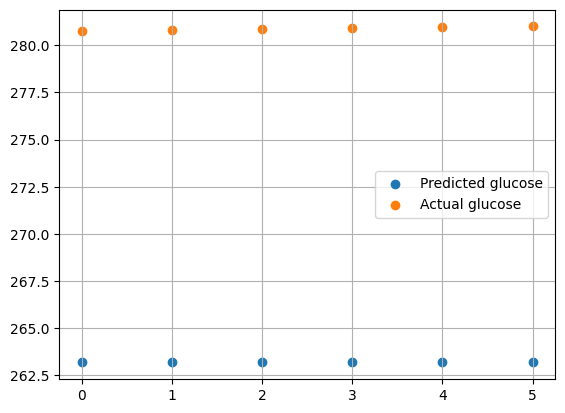

In [109]:
with torch.no_grad():
    for x in test_loader:
        batch = x[0]
        x = batch[:, :-1]
        y = batch[:, -1]
        output_model = model(x.unsqueeze(-1))
        mape = mean_absolute_percentage_error(y, output_model)
        mae = mean_absolute_error(y, output_model)
        mse = mean_squared_error(y, output_model)
        print(f'MAPE:{mape}')
        print(f'MAE:{mae}')
        print(f'MSE:{mse}')
        plt.scatter(range(y.size()[0]), output_model, label='Predicted glucose')
        plt.scatter(range(y.size()[0]), y, label='Actual glucose')
        plt.legend()
        plt.grid()
        plt.show()

Register our model using mlflow 

In [57]:
import mlflow
from mlflow import MlflowClient
from mlflow.models import infer_signature

In [58]:
params = {'batch_size' : batch_size, 
          'input_size' : input_size, 
          'hidden_size' : hidden_size, 
          'window_size' : window_size,
          'optimizer' : optimizer.__class__,
          'learning_rate' : 0.001,
          'loss_function' : loss_function.__class__,
          'epochs' : epochs,
          'steps_ahead' : steps_ahead
}
metrics = {'mae' : mae,
           'mape' : mape,
           'mse' : mse,
           'last_train_loss' : 157.8843
}

Just to log the model along with a signature 

In [59]:
example_input = torch.randn((batch_size, window_size, input_size))
example_output = model(example_input)
signature = infer_signature(example_input.numpy(), example_output.detach().numpy())

In [60]:
''' 
mlflow.set_tracking_uri(uri='http://127.0.0.1:8080')
mlflow.set_experiment('LSTM_two_recurrent_layers')
with mlflow.start_run(run_name='LSTM with just one recurrent layers'):
    mlflow.log_params(params)
    mlflow.log_metrics(metrics)
    mlflow.pytorch.log_model(model, 'lstm_one_layer', signature=signature)
    '''

" \nmlflow.set_tracking_uri(uri='http://127.0.0.1:8080')\nmlflow.set_experiment('LSTM_two_recurrent_layers')\nwith mlflow.start_run(run_name='LSTM with just one recurrent layers'):\n    mlflow.log_params(params)\n    mlflow.log_metrics(metrics)\n    mlflow.pytorch.log_model(model, 'lstm_one_layer', signature=signature)\n    "

Now, let's try a recursive prediction 

In [61]:
def predict_recursive(model, last_window, n_steps):
    with torch.no_grad():
        model.eval()
        window = last_window.clone().detach()  # (L,)
        predictions = []

        for _ in range(n_steps):
            # Preparar entrada: (1, L, 1) → batch=1, seq=L, features=1
            x = window.unsqueeze(0).unsqueeze(-1)  # (1, L, 1)
            
            with torch.no_grad():
                pred = model(x)  # (1,)
            
            pred_val = pred.item()
            predictions.append(pred_val)
            
            # Actualizar ventana: quitar el primero, añadir la predicción
            window = torch.cat([window[1:], torch.tensor([pred_val])])

        return predictions

In [62]:
predict_recursive(model, last_window=torch.tensor([171.333333, 168.666667, 166.000000, 163.333333]), n_steps=6)

[160.47140502929688,
 157.40194702148438,
 153.9867706298828,
 150.0271453857422,
 145.04812622070312,
 138.0176544189453]

As we could see, recursive prediction does not perform well, since we are basically training our network to predict the next step even if we use a window